In [1]:
from data_process import prepare
import os
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

2025-01-07 19:53:23.008574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered


In [2]:
print(tf.__version__)

2.17.0


In [3]:
# Load the best model
model_path = os.getcwd() + '/saved_models/best_model.keras'
best_model = keras.models.load_model(model_path)
best_model.summary()

Model: "classifier_to_explain"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 256, 256, 1)    │       131,073 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,031,692 (49.71 MB)

 Trainable params: 4,300,131 (16.40 MB)

 Non-trainable params: 131,297 (512.88 KB)

 Optimizer params: 8,600,264 (32.81 MB)

In [4]:
labels = np.load('./dataset/labels.npy')
images = np.load('./dataset/images.npy', mmap_mode='r')
masks = np.load('./dataset/masks.npy', mmap_mode='r')
patient_ids = np.load('./dataset/patient_ids.npy').flatten()
file_paths = np.load('./dataset/file_paths.npy')

integer_to_class = {'1': 'meningioma (1)', '2': 'glioma (2)', '3': 'pituitary tumor (3)'}

In [5]:
ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
ds = prepare(ds, shuffle=False, augment=False)

In [6]:
def get_example_by_idx(ds, i):
    """
    Return the example at index i in the dataset ds
    """
    ds_iterator = iter(ds)
    X, y = next(ds_iterator)
    while i >= X.shape[0]:
        try:
            i -= X.shape[0]
            X, y = next(ds_iterator)
        except StopIteration:
            return None
    return tf.cast(X[i], tf.float32) , y[i]
        

# Feature attribution for explaining classifier predictions

## Saliency maps

In [6]:
def compute_saliency_map(model, x, y):
    """
    Return a 2D array representing gradient magnitude of each input feature of x
    w.r.t to the highest class activation for x.
    """
    with tf.GradientTape() as tape:
        tape.watch(x)
        # expand dims to create a "batch" with a single example
        class_activations = best_model(tf.expand_dims(x, 0))
        class_activations = tf.squeeze(class_activations)
        largest_activation = class_activations[np.argmax(class_activations)]
    
    grad_x = tape.gradient(largest_activation, x).numpy()
    bg_ind = (x.numpy() > (10 ** 2)).astype(int)
    grad_mag_x = np.abs(grad_x) * bg_ind
    
    print(np.min(grad_mag_x), np.max(grad_mag_x), np.median(grad_mag_x))
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(x, cmap='gray')
    ax[0].set_title(f'{y} example')
    ax[1].imshow(grad_mag_x, vmin=np.min(grad_mag_x), vmax=np.percentile(grad_mag_x, 99) , cmap='gray')
    ax[1].set_title('Saliency Map')
    

0.0 1.957116246842361e-09 9.487482847958528e-12


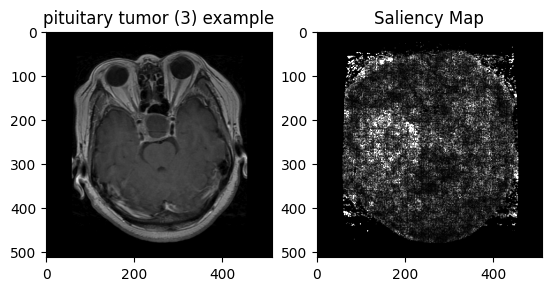

In [8]:
X, y = get_example_by_idx(ds,15)
compute_saliency_map(best_model, X, integer_to_class[str(np.argmax(y) + 1)])

## Grad-CAM

In [15]:
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

def convert_sequential_to_functional(sequential_model):
    # Extract the input layer from the first layer of the sequential model
    inputs = tf.keras.Input(shape=sequential_model.input_shape[1:])
    
    # Pass the inputs through each layer of the sequential model
    x = inputs
    for layer in sequential_model.layers:
        x = layer(x)
    
    # Create a functional model with the same inputs and outputs
    functional_model = Model(inputs=inputs, outputs=x)
    return functional_model


def compute_gradcam(model, x, y):

    feature_extractor = keras.Model(
        inputs=model.inputs,
        outputs=[layer.output for layer in model.layers],
    )

    last_conv_layer_name = "conv2d_3"
    last_conv_layer = model.get_layer(last_conv_layer_name)

    dropout_layer = model.get_layer("dropout")
    dense_layer = model.get_layer("dense_1")

    input_tensor = tf.expand_dims(x, 0)

    with tf.GradientTape() as tape:

        conv_outputs_variable = tf.Variable(last_conv_layer.output)
        tape.watch(conv_outputs_variable)  # Watch the input tensor for gradient computation

        layer_outputs = feature_extractor(input_tensor)
        preds = model(input_tensor)
        
        dense_layer_weights = dense_layer.get_weights()
        # logits = (dense_layer_weights[0].T @ preds[-2].numpy().T) + dense_layer_weights[1].reshape((3, 1))
        logits = tf.matmul(layer_outputs[-2], tf.convert_to_tensor(dense_layer_weights[0])) + tf.convert_to_tensor(dense_layer_weights[1])

        print("Pre-softmax logits ", logits)

        pred_class = np.argmax(logits[0])  # Predicted class
        pred_score = logits[0, pred_class]
        conv_outputs = last_conv_layer.output
        print("Final conv. layer outputs ", conv_outputs)
        grads = tape.gradient(pred_score, conv_outputs_variable)
        print("Gradient of prediction score w.r.t final conv layer outputs ", grads)
        
    # # Get the gradient of the target class score with respect to the feature map
    # with tf.GradientTape() as tape:
    #     conv_outputs, predictions = grad_model(input_tensor)
    
    # # Compute the gradient of the loss with respect to the convolutional layer outputs
    
    # # Compute the mean intensity of the gradients across the feature map
    # pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # # Multiply each feature map by its importance and sum to get the heatmap
    # conv_outputs = conv_outputs[0]
    # pooled_grads = pooled_grads.numpy()
    # heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    # heatmap = np.maximum(heatmap, 0) / np.max(heatmap)  # ReLU and normalize

    # # Resize heatmap to match the original image size
    # heatmap = cv2.resize(heatmap.numpy(), (img.size[0], img.size[1]))
    
    # # Convert heatmap to RGB
    # heatmap = np.uint8(255 * heatmap)
    # heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # # Superimpose the heatmap on the original image
    # superimposed_img = cv2.addWeighted(img_to_array(img).astype('uint8'), 0.6, heatmap, 0.4, 0)
    
    # # Display the image
    # plt.imshow(superimposed_img / 255.0)  # Scale to [0, 1]
    # plt.axis('off')
    # plt.show()

    # # Convert Sequential to Functional if needed
    # if isinstance(model, tf.keras.Sequential):
    #     model = convert_sequential_to_functional(model)
    #     print(model.summary())

    
    # _ = model(input_tensor)

    # preds = model.predict(input_tensor)    
    # print(preds)
    # predicted_class = np.argmax(preds)
    # score = CategoricalScore([predicted_class])


    # gradcam = Gradcam(model, model_modifier=ReplaceToLinear(), clone=True)
    
    
    # # Find the last conv layer name
    # for layer in model.layers:
    #     print(layer.name)
    
    # # Generate Grad-CAM heatmap
    # print(score)
    # print(f"Input tensor type: {type(input_tensor)}")
    # print(f"Input tensor shape: {input_tensor.shape}")
    # cam = gradcam(score, input_tensor, penultimate_layer='conv2d_3')  # Use the last conv layer
    # print(cam)
    # # Visualize the heatmap
    # heatmap = cam[0]
    # plt.imshow(heatmap, cmap='jet', alpha=0.8)
    # # plt.imshow(x, alpha=0.5)
    # plt.axis('off')
    # plt.show()

In [16]:
X, y = get_example_by_idx(ds,15)
compute_gradcam(best_model, X, integer_to_class[str(np.argmax(y) + 1)])

ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```
